# Exp 07 — mT5-base + LoRA + beam search inference

**Model context.** Greedy decoding replaced with beam search at inference; trained weights unchanged from Exp 06.

*Multilingual Health QA in Low-Resource African Languages — fine-tuning experiment 07.*

## Install dependencies
Pin `peft` to a compatible build and install only the packages not already present, without upgrading the pre-installed PyTorch (this keeps the CUDA build matched to the GPU). If `get_peft_model` raises a torchao error, restart the kernel once and run from the top.

In [1]:
!pip install -q "peft==0.14.0" datasets rouge-score sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu1

## Paths
Input CSVs are read from the dataset directory and all outputs are written to the working directory, which persists with the saved run.

In [2]:
DATA_DIR = '/kaggle/input/datasets/miraclenanenmbanaade/multilingual-health-qa/'
SAVE_DIR = '/kaggle/working/outputs/'
CKPT_DIR = '/kaggle/working/checkpoints/exp05/'

import os
for d in [SAVE_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Files in DATA_DIR:', os.listdir(DATA_DIR))

Files in DATA_DIR: ['Val.csv', 'Train.csv', 'Test.csv']


## Imports and reproducibility
Fix all random seeds so the run is reproducible, and select the GPU device.

In [3]:
import random, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from rouge_score import rouge_scorer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## Load data
Read the train, validation, and test splits.

In [4]:
train_df = pd.read_csv(DATA_DIR + 'Train.csv')
val_df   = pd.read_csv(DATA_DIR + 'Val.csv')
test_df  = pd.read_csv(DATA_DIR + 'Test.csv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 29815 | Val: 6686 | Test: 2618


## Parse language and country
The `subset` code (e.g. `Lug_Uga`) encodes the language and country. Map it to readable fields so they can be injected into the prompt and used for per-language analysis.

In [5]:
SUBSET_MAP = {
    'Aka_Gha': ('Akan',    'Ghana'),
    'Amh_Eth': ('Amharic', 'Ethiopia'),
    'Lug_Uga': ('Luganda', 'Uganda'),
    'Swa_Ken': ('Swahili', 'Kenya'),
    'Swa_Tan': ('Swahili', 'Tanzania'),
    'Swa_Uga': ('Swahili', 'Uganda'),
    'Eng_Gha': ('English', 'Ghana'),
    'Eng_Uga': ('English', 'Uganda'),
    'Eng_Ken': ('English', 'Kenya'),
}

for df in [train_df, val_df, test_df]:
    df['language'] = df['subset'].map(lambda s: SUBSET_MAP.get(s, (s, ''))[0])
    df['country']  = df['subset'].map(lambda s: SUBSET_MAP.get(s, ('', s))[1])

print(train_df[['subset','language','country']].drop_duplicates().sort_values('subset').to_string(index=False))

 subset language  country
Aka_Gha     Akan    Ghana
Amh_Eth  Amharic Ethiopia
Eng_Eth  Eng_Eth  Eng_Eth
Eng_Gha  English    Ghana
Eng_Ken  English    Kenya
Eng_Uga  English   Uganda
Lug_Uga  Luganda   Uganda
Swa_Ken  Swahili    Kenya


## Clean text and build prompts
Normalise whitespace, then build a structured prompt that tells the model which language and country to answer in. Conditioning on language is intended to encourage same-language responses.

In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    return re.sub(r' {2,}', ' ', text).strip()

def build_prompt(question, language, country=''):
    header = f'Language: {language}'
    if country:
        header += f' | Country: {country}'
    return f'{header}\nQuestion: {question}\nAnswer:'

for df in [train_df, val_df, test_df]:
    df['input_clean'] = df['input'].apply(clean_text)
    df['prompt_text'] = df.apply(
        lambda r: build_prompt(r['input_clean'], r['language'], r['country']), axis=1
    )

for df in [train_df, val_df]:
    df['output_clean'] = df['output'].apply(clean_text)

print(train_df['prompt_text'].iloc[0])
print()
print(train_df['output_clean'].iloc[0])

Language: Akan | Country: Ghana
Question: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer:

Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa sɛ wɔpɛ sɛ wɔde mmara kwan so asɛm bɛkɔ atia nea ɔyɛɛ wɔ bɔne no a. Su ne nneyɛe a wɔde to nea wɔayɛ no bɔne so a wɔbɛkasa atia denam si a wobesi so dua sɛ asɛyɛde no da nea ɔyɛɛ bɔne no so,

## Exploratory data analysis
Before modeling, examine the dataset: how examples are distributed across languages, and how long the questions and answers are. These checks reveal class imbalance and inform the choice of `MAX_INPUT_LEN` / `MAX_TARGET_LEN`.

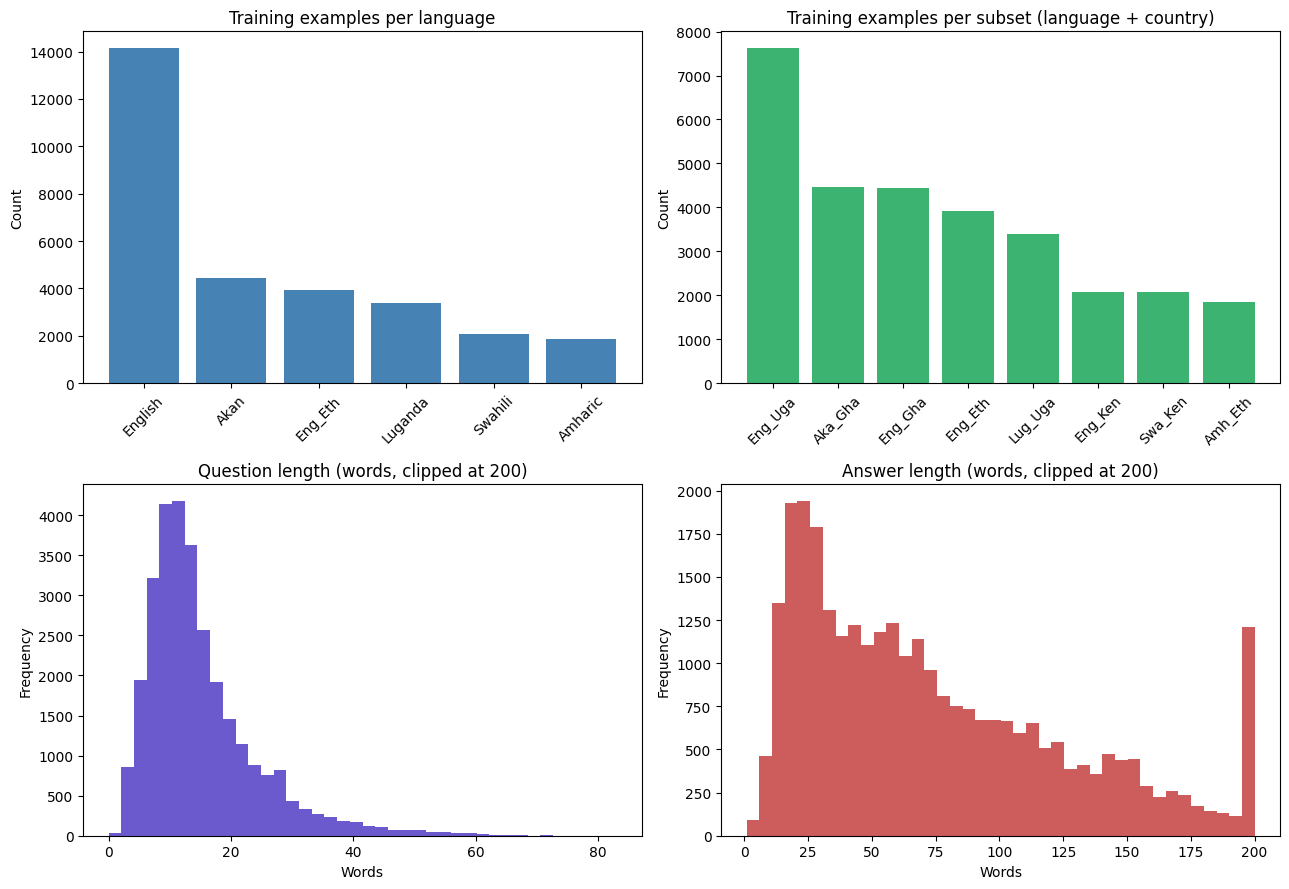

Question words  — median: 13 | 95th pct: 34
Answer words    — median: 61 | 95th pct: 184


In [7]:
train_df['q_words'] = train_df['input_clean'].str.split().str.len()
train_df['a_words'] = train_df['output_clean'].str.split().str.len()

lang_counts = train_df['language'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].bar(lang_counts.index, lang_counts.values, color='steelblue')
axes[0, 0].set_title('Training examples per language')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

subset_counts = train_df['subset'].value_counts()
axes[0, 1].bar(subset_counts.index, subset_counts.values, color='mediumseagreen')
axes[0, 1].set_title('Training examples per subset (language + country)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].hist(train_df['q_words'].clip(upper=200), bins=40, color='slateblue')
axes[1, 0].set_title('Question length (words, clipped at 200)')
axes[1, 0].set_xlabel('Words')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(train_df['a_words'].clip(upper=200), bins=40, color='indianred')
axes[1, 1].set_title('Answer length (words, clipped at 200)')
axes[1, 1].set_xlabel('Words')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'exp07_eda_overview.png', dpi=150)
plt.show()

print('Question words  — median:', int(train_df['q_words'].median()), '| 95th pct:', int(train_df['q_words'].quantile(0.95)))
print('Answer words    — median:', int(train_df['a_words'].median()), '| 95th pct:', int(train_df['a_words'].quantile(0.95)))

## Tokenize
Tokenize with truncation but no fixed padding; the data collator pads each batch to its own longest sequence, which is faster than padding everything to the maximum length.

In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME     = 'google/mt5-base'
MAX_INPUT_LEN  = 384
MAX_TARGET_LEN = 200

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    model_inputs = tokenizer(batch['prompt_text'], max_length=MAX_INPUT_LEN, truncation=True)
    labels = tokenizer(text_target=batch['output_clean'], max_length=MAX_TARGET_LEN, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_hf  = Dataset.from_pandas(train_df[['prompt_text', 'output_clean']].reset_index(drop=True))
val_hf    = Dataset.from_pandas(val_df[['prompt_text', 'output_clean']].reset_index(drop=True))
train_tok = train_hf.map(tokenize, batched=True, remove_columns=train_hf.column_names, desc='Train')
val_tok   = val_hf.map(tokenize,   batched=True, remove_columns=val_hf.column_names,   desc='Val')

print(f'Tokenized — Train: {len(train_tok)} | Val: {len(val_tok)}')

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Train:   0%|          | 0/29815 [00:00<?, ? examples/s]

Val:   0%|          | 0/6686 [00:00<?, ? examples/s]

Tokenized — Train: 29815 | Val: 6686


## Load model with LoRA
Load mT5-base in bfloat16 and apply LoRA to the full attention block plus the feed-forward projections, the configuration that performed best in Exp 05.

In [9]:
from transformers import AutoModelForSeq2SeqLM
from peft import LoraConfig, TaskType, get_peft_model

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    tie_word_embeddings=False,
)
model.to(DEVICE)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=['q', 'k', 'v', 'o', 'wi', 'wo'],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 4,620,288 || all params: 971,193,600 || trainable%: 0.4757


## Fine-tune
Train for 3 epochs in bf16. Batch size is reduced and gradient accumulation increased relative to Exp 05 because mT5-base uses more memory; the effective batch size stays similar.

In [10]:
from transformers import (
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

training_args = Seq2SeqTrainingArguments(
    output_dir=CKPT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=3e-4,
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    bf16=True,
    fp16=False,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    predict_with_generate=False,
    logging_steps=50,
    seed=SEED,
    report_to='none',
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, pad_to_multiple_of=8, label_pad_token_id=-100
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,26.850625,5.384607
2,24.603125,5.032334
3,24.378750,4.979777


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=2796, training_loss=30.041733726752504, metrics={'train_runtime': 15270.6309, 'train_samples_per_second': 5.857, 'train_steps_per_second': 0.183, 'total_flos': 1.7470802707808256e+16, 'train_loss': 30.041733726752504, 'epoch': 3.0})

## Learning curves
Plot training and validation loss and save the figure for the report.

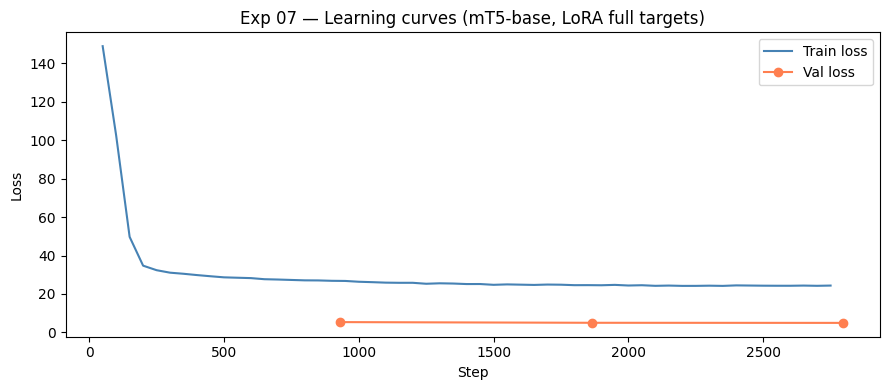

In [11]:
log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([x['step'] for x in train_logs], [x['loss'] for x in train_logs], label='Train loss', color='steelblue')
ax.plot([x['step'] for x in eval_logs],  [x['eval_loss'] for x in eval_logs], label='Val loss', color='coral', marker='o')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Exp 07 — Learning curves (mT5-base, LoRA full targets)')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'exp07_learning_curve.png', dpi=150)
plt.show()

## Generation and ROUGE helpers
Beam search (`num_beams=4`) replaces greedy decoding to improve fluency. `no_repeat_ngram_size` prevents repeated phrases and `length_penalty` discourages overly short answers. This is the core change of the experiment.

In [12]:
_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)

def evaluate_rouge(predictions, references):
    r1s, rls = [], []
    for pred, ref in zip(predictions, references):
        s = _scorer.score(ref, pred)
        r1s.append(s['rouge1'].fmeasure)
        rls.append(s['rougeL'].fmeasure)
    return {'rouge1': round(sum(r1s)/len(r1s), 4), 'rougeL': round(sum(rls)/len(rls), 4)}

def generate_batch(prompts, batch_size=8, max_new_tokens=200):
    model.eval()
    predictions = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch  = prompts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=MAX_INPUT_LEN).to(model.device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                no_repeat_ngram_size=3,
                length_penalty=1.0,
                early_stopping=True,
            )
        predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return predictions

## Validate on a sample
Score a 500-row validation sample for a fast, reliable ROUGE estimate. The estimated leaderboard value uses the same 0.37 / 0.37 weighting Zindi applies to the two ROUGE metrics.

In [13]:
val_sample = val_df.sample(n=500, random_state=SEED).reset_index(drop=True)

val_preds  = generate_batch(val_sample['prompt_text'].tolist())
val_scores = evaluate_rouge(val_preds, val_sample['output_clean'].tolist())

print(f"ROUGE-1 F1 : {val_scores['rouge1']}")
print(f"ROUGE-L F1 : {val_scores['rougeL']}")
print(f"Est. LB    : {0.37*val_scores['rouge1'] + 0.37*val_scores['rougeL']:.4f}  (ROUGE only)")

  0%|          | 0/63 [00:00<?, ?it/s]

ROUGE-1 F1 : 0.2304
ROUGE-L F1 : 0.1684
Est. LB    : 0.1476  (ROUGE only)


## Per-language breakdown
Average ROUGE per language on the sample to see which languages the model handles well and which lag.

In [14]:
rows = []
for pred, ref, lang in zip(val_preds, val_sample['output_clean'], val_sample['language']):
    s = _scorer.score(ref, pred)
    rows.append({'language': lang, 'rouge1': s['rouge1'].fmeasure, 'rougeL': s['rougeL'].fmeasure})

summary = (
    pd.DataFrame(rows)
    .groupby('language')
    .agg(rouge1=('rouge1','mean'), rougeL=('rougeL','mean'), count=('rouge1','count'))
    .round(4).reset_index().sort_values('rougeL', ascending=False)
)
print(summary.to_string(index=False))

language  rouge1  rougeL  count
 Eng_Eth  0.2708  0.2453     33
    Akan  0.3681  0.2435     73
 English  0.2392  0.1734    237
 Swahili  0.2256  0.1729     41
 Luganda  0.1780  0.1303     70
 Amharic  0.0217  0.0217     46


## Evaluation visualizations
Two views of performance: ROUGE per language (where does the model do well or poorly?) and a comparison of leaderboard scores across all experiments logged so far.

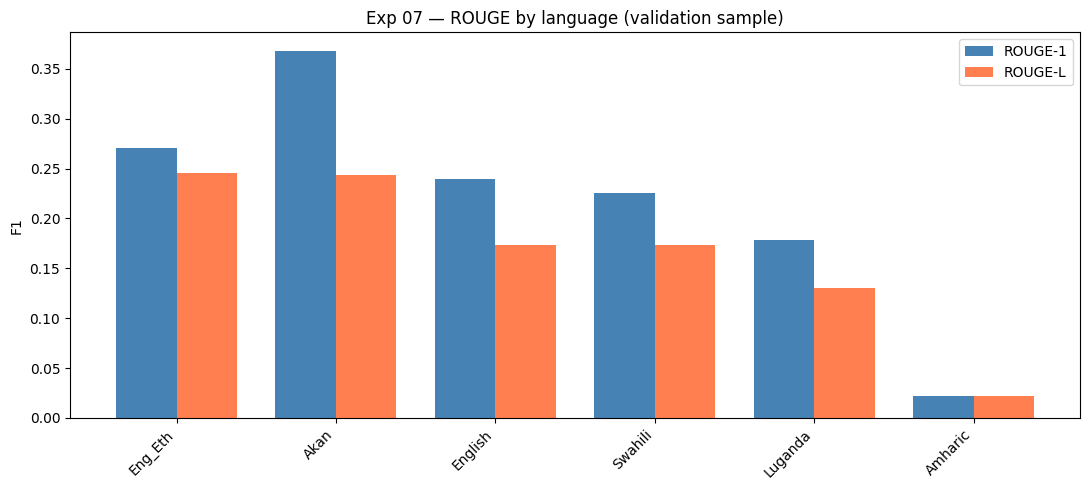

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
width = 0.38
ax.bar(x - width/2, summary['rouge1'], width, label='ROUGE-1', color='steelblue')
ax.bar(x + width/2, summary['rougeL'], width, label='ROUGE-L', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(summary['language'], rotation=45, ha='right')
ax.set_ylabel('F1')
ax.set_title('Exp 07 — ROUGE by language (validation sample)')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'exp07_rouge_by_language.png', dpi=150)
plt.show()

## Results

Final results across all experiments (leaderboard and validation metrics). This experiment is **Exp 07**.

| Exp | Model | Key change | Decoding | Zindi LB | ROUGE-1 | ROUGE-L | LLM-Judge |
|-----|-------|-----------|----------|----------|---------|---------|-----------|
| Exp 01 | mt5-small | zero-shot baseline | greedy | 0.0017 | 0.0001 | 0.0001 | — |
| Exp 03 | mt5-small | LoRA r=8, attention (q,v) | greedy | — | — | — | — |
| Exp 04 | mt5-small | LoRA r=16, attention (q,v) | greedy | 0.1218 | 0.1839 | 0.1453 | 0.0 |
| Exp 05 | mt5-small | LoRA full attention + FFN | greedy | 0.1598 | 0.1713 | 0.1380 | 0.1746 |
| Exp 06 | mt5-base | scaled model, full targets | greedy | 0.1811 | 0.2077 | 0.1668 | 0.1638 |
| Exp 07 | mt5-base | beam search (num_beams=4) | beam=4 | 0.2536 | 0.2530 | 0.1811 | 0.3576 |
| Exp 08 | mt5-base | 5 epochs (champion) | beam=4 | 0.2613 | 0.2760 | 0.1923 | 0.3384 |
| Exp 09 | mt5-base | LoRA r=32 | beam=4 | 0.2554 | 0.2678 | 0.1879 | 0.3337 |
| Exp 10 | mt5-base | richer prompt + length_penalty | beam=4 | not submitted | — | — | — |
| Exp 11 | mt5-base | lower LR 2e-4 + warmup | beam=4 | not submitted | — | — | — |

**Insight.** Replacing greedy decoding with beam search (num_beams=4), with no change to the trained weights, was the single largest improvement of the project: the score rose from 0.1811 to 0.2536 and the LLM-Judge more than doubled (0.1638 to 0.3576). Because only decoding changed, the gain is cleanly attributable to inference strategy. Greedy decoding had been producing literal, often truncated text; beam search explores multiple candidate sequences and selects the most coherent, which the judge rewards strongly.

## Generate test submission
Generate predictions for every test row (all rows are required by Zindi) and write the submission in the multi-metric format: the predicted text is placed in all three target columns.

In [16]:
test_preds = generate_batch(test_df['prompt_text'].tolist())

submission = pd.DataFrame({
    'ID':         test_df['ID'].values,
    'TargetRLF1': test_preds,
    'TargetR1F1': test_preds,
    'TargetLLM':  test_preds,
})

out_path = SAVE_DIR + 'exp07_mt5base_beam.csv'
submission.to_csv(out_path, index=False)
print('Saved:', out_path)
submission.head(3)

  0%|          | 0/328 [00:00<?, ?it/s]

Saved: /kaggle/working/outputs/exp07_mt5base_beam.csv


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumay..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun a wɔbɛtumi afi hokwan a mmabun wɔ sɛ wo...,Mmabun a wɔbɛtumi afi hokwan a mmabun wɔ sɛ wo...,Mmabun a wɔbɛtumi afi hokwan a mmabun wɔ sɛ wo...
2,ID_TS_Aka_Gha_06671AD1,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi a...
